# MWE: imaging with a long-baseline interferometer, over two nights and many channels

Long-baseline interferometers such as the VLTI give the same kinds of data as an aperture mask, squared visibilities and closure phases, but from a few telescopes on baselines of tens of metres, with the uv coverage filled in by Earth rotation through the night and by many wavelength channels. Two complications follow. Data from several nights have to be fitted together, and over a wide band the extended emission's flux relative to the star changes with wavelength, so a grey image needs a spectrum alongside it, as in SPARCO (Kluska et al. 2014).

This notebook simulates two nights of four-UT, MATISSE-like L-band observations with `virgil.coverage.vlti_oidata` (eleven channels from 3 to 4 µm) of a star with an inclined ring and a blob around it, whose flux relative to the star rises as a power law in wavelength. It then reconstructs the image and fits the power law's ratio and index at the same time, over both nights jointly. You should come away knowing how to set up a multi-night, chromatic image fit with `fit` and `l_curve`.

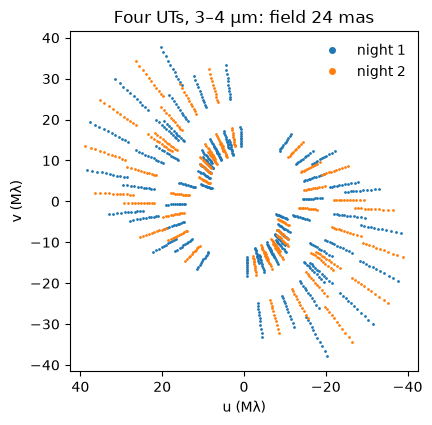

In [1]:
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro.distributions as dist

from virgil.coverage import vlti_oidata
from virgil.imaging import MaxEntropy, beam, diagnose, field_of_view, image_priors, l_curve, starting_image
from virgil.models import Image, PointSource, System
from virgil.plotting import plot_model, plot_residual_map
from virgil.scenes import gaussian_blob, ring
from virgil.spectra import PowerLaw

templates = [vlti_oidata(hour_angles_h=(-3.0, -1.5, 0.0, 1.5, 3.0)), vlti_oidata(hour_angles_h=(-2.25, -0.75, 0.75, 2.25))]
fov, npix = field_of_view(templates[0]), 40
scale = fov / npix
truth_image = 0.8 * ring(npix, scale, 6.0, 1.0, inc_deg=50.0, pa_deg=30.0, asymmetry=0.4, asymmetry_pa_deg=90.0) + 0.2 * gaussian_blob(npix, scale, 0.5, dra=-7.0, ddec=5.0)
truth_image = truth_image / truth_image.sum()
truth = System(star=PointSource(), env=Image.from_brightness(truth_image, scale, flux=PowerLaw(0.5, 2.0, 3.5e-6)))
nights = [t.with_model(truth, key=jax.random.PRNGKey(k)) for k, t in enumerate(templates)]

fig, ax = plt.subplots(figsize=(4.5, 4.5))
for d, label in zip(nights, ("night 1", "night 2")):
    u, v = d.u / d.wavel / 1e6, d.v / d.wavel / 1e6
    ax.plot(jnp.concatenate([u, -u]).ravel(), jnp.concatenate([v, -v]).ravel(), ".", ms=2, label=label)
ax.set(xlabel="u (Mλ)", ylabel="v (Mλ)", title=f"Four UTs, 3–4 µm: field {fov:.0f} mas", aspect="equal")
ax.invert_xaxis()
ax.legend(frameon=False, markerscale=4)
plt.show()

## A grey image with a power-law spectrum

`starting_image` fits a star plus a Gaussian envelope to both nights and builds a starting image within the interferometric field of view, λ/B over the shortest baseline. The image's support has a hole of half a beam under the star (`hole_mas`): flux there is nearly indistinguishable from the star's, and if the image could put flux there, it would trade it against the star's and bias the fitted spectrum's ratio. Its scalar flux is then replaced by a `PowerLaw` with index zero at 3.5 µm, and priors on `"env.flux.ratio"` and `"env.flux.index"` are added to the pixel priors, so that the spectrum is fitted together with the image. `l_curve` sweeps the maximum-entropy weight over both nights jointly, and the image where χ² per data point reaches one in the worse-fitted night is kept.

In [2]:
start = starting_image(nights, hole_mas=0.5 * beam(nights).minor_mas)
start = start.set("env.flux", PowerLaw(start.env.flux, 0.0, 3.5e-6))
priors = image_priors(start) | {"env.flux.ratio": dist.Uniform(0.0, 5.0), "env.flux.index": dist.Uniform(-6.0, 6.0)}
curve = l_curve(start, priors, nights, MaxEntropy(1.0, path="env"), jnp.logspace(-1, 4, 11))
weight = curve.discrepancy() or curve.corner()
chosen = int(jnp.argmin(jnp.abs(jnp.log(curve.weights) - jnp.log(weight))))
result = curve.results[chosen].model
print(f"{sum(d.vis.size + d.phi.size for d in nights)} data over two nights; {start.env.log_brightness.shape[0]}² pixels of {start.env.pixel_scale_mas:.2f} mas")
print(f"discrepancy weight {weight:.3g}; chi2 per point by night: {', '.join(f'{c:.2f}' for c in curve.chi2_red[chosen])}")
print(f"flux ratio at 3.5 µm: {float(result.env.flux.ratio):.3f} (truth 0.5); index: {float(result.env.flux.index):.2f} (truth 2)")

/var/tmp/jobfs/virgil/src/virgil/imaging.py:1252: RuntimeWarning: fit(method='lbfgs') did not converge in 20000 steps, the step limit; raise max_steps.
  result = fit(


990 data over two nights; 41² pixels of 0.59 mas
discrepancy weight 38.8; chi2 per point by night: 0.99, 0.98
flux ratio at 3.5 µm: 0.506 (truth 0.5); index: 1.89 (truth 2)


## The reconstruction

The truth, the reconstruction at the discrepancy weight with the beam shaded, and their signed difference (a MAP image has no uncertainties, so these are not z-scores). With four telescopes the beam is elongated along the direction in which the uv tracks are shortest. The ring, only a couple of beams across, is recovered with its inclination and its brighter eastern side, and the blob to the north-west is recovered at the right place, a little broadened by the regulariser; the faint western arc of the ring is the least well reconstructed part.

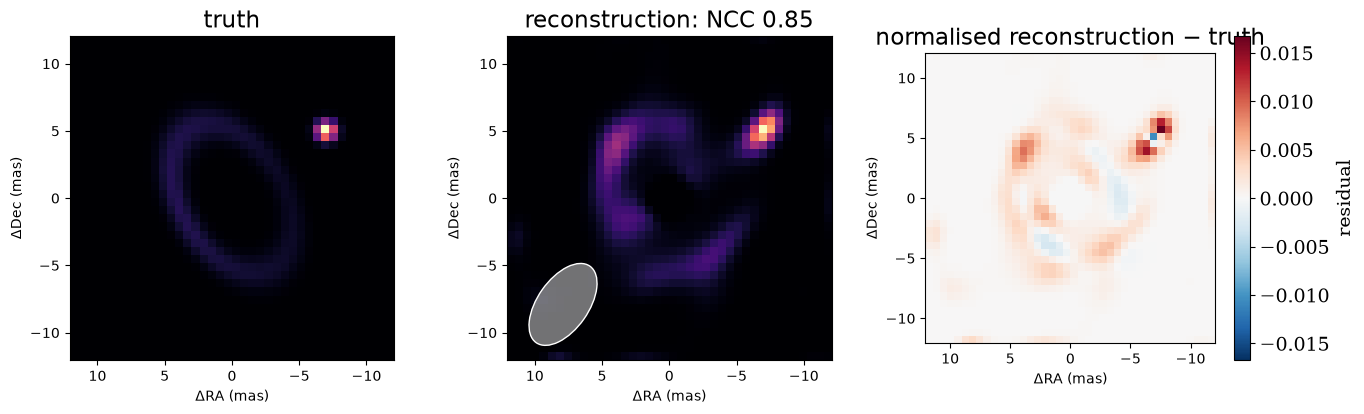

In [3]:
def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


image = result.env.render(npix, fov) / float(result.env.flux.ratio)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
plot_model(truth.env, fov_mas=fov, npix=npix, ax=axes[0], title="truth")
plot_model(result.env, fov_mas=fov, npix=npix, ax=axes[1], title=f"reconstruction: NCC {ncc(image, truth_image):.2f}", beam=beam(nights))
plot_residual_map(image - truth_image, fov_mas=fov, ax=axes[2], title="normalised reconstruction − truth")
plt.tight_layout()
plt.show()

## The spectrum

The fitted and true flux of the extended emission relative to the star, across the band. SPARCO separates the two because the star is unresolved: its visibility is one at every wavelength, so the chromatic part of the data's visibility drop belongs to the emission around it.

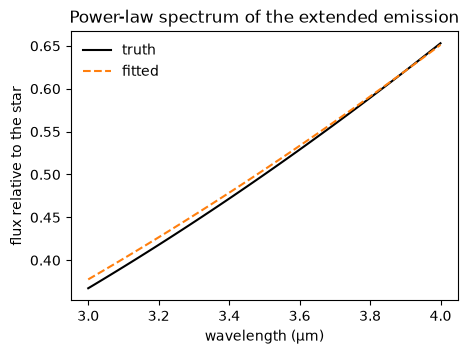

In [4]:
wavel = jnp.linspace(3.0e-6, 4.0e-6, 50)
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(wavel * 1e6, truth.env.flux(wavel), "k-", label="truth")
ax.plot(wavel * 1e6, result.env.flux(wavel), "C1--", label="fitted")
ax.set(xlabel="wavelength (µm)", ylabel="flux relative to the star", title="Power-law spectrum of the extended emission")
ax.legend(frameon=False)
plt.show()

## Diagnostics

`diagnose` on the reconstruction and both nights. χ² per point is near one in each, the image is anchored by the star, little flux reaches the edge of the field, and rotating the image by 180° makes χ² far worse, so the closure phases fix its orientation.

In [5]:
print(diagnose(result, nights))

chi2_red         [0.994, 0.98]
anchored         True
pixel_scale_mas  [0.594]
edge_flux        [0.0371]
centroid_mas     [[-0.558, 1.02]]
flip_dchi2       7.51e+04

No warnings.


## Summary

Two nights of four-telescope, eleven-channel data were fitted jointly by passing a list of datasets to `l_curve` (and so to `fit`), and the emission's spectrum was fitted alongside its image by giving the `Image` a `PowerLaw` flux with priors on its ratio and index. Nothing in the fitting code is specific to the VLTI: the same calls work for aperture-masking data, as in the previous MWE. The field is limited to λ/B over the shortest baseline, so objects much larger than that need shorter baselines, such as the AT configurations, rather than a bigger image.